### Mount Google Drive and Unzip Datasets

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Now, let's unzip the files into the session storage.

In [2]:
import zipfile
import os

# Define paths for the zip files in Google Drive
cicids_zip_path = '/content/drive/MyDrive/CICIDS2017.zip'
unsw_nb15_zip_path = '/content/drive/MyDrive/UNSW-NB15.zip'

# Define destination directories in session storage
cicids_extract_path = './CICIDS2017_extracted'
unsw_nb15_extract_path = './UNSW_NB15_extracted'

os.makedirs(cicids_extract_path, exist_ok=True)
os.makedirs(unsw_nb15_extract_path, exist_ok=True)

print(f"Unzipping {cicids_zip_path} to {cicids_extract_path}...")
with zipfile.ZipFile(cicids_zip_path, 'r') as zip_ref:
    zip_ref.extractall(cicids_extract_path)
print("CICIDS2017 unzipped successfully.")

print(f"Unzipping {unsw_nb15_zip_path} to {unsw_nb15_extract_path}...")
with zipfile.ZipFile(unsw_nb15_zip_path, 'r') as zip_ref:
    zip_ref.extractall(unsw_nb15_extract_path)
print("UNSW-NB15 unzipped successfully.")

Unzipping /content/drive/MyDrive/CICIDS2017.zip to ./CICIDS2017_extracted...
CICIDS2017 unzipped successfully.
Unzipping /content/drive/MyDrive/UNSW-NB15.zip to ./UNSW_NB15_extracted...
UNSW-NB15 unzipped successfully.


Next, I will combine all the CSV files from each dataset into a single pandas DataFrame.

In [3]:
import pandas as pd
import os
import numpy as np

def downcast_dtypes(df):
    """
    Downcasts numeric columns to more memory-efficient types.
    """
    original_mem = df.memory_usage(deep=True).sum() / (1024**2)
    for col in df.columns:
        if df[col].dtype == 'int64':
            df[col] = pd.to_numeric(df[col], downcast='integer')
        elif df[col].dtype == 'float64':
            df[col] = pd.to_numeric(df[col], downcast='float')
    new_mem = df.memory_usage(deep=True).sum() / (1024**2)
    print(f"Memory reduced for DataFrame from {original_mem:.2f} MB to {new_mem:.2f} MB")
    return df


def combine_csv_files(directory_path):
    all_files = [os.path.join(directory_path, f) for f in os.listdir(directory_path) if f.endswith('.csv')]
    li = []
    for filename in all_files:
        # Using low_memory=False for better type inference across chunks of large files.
        # This might temporarily increase memory during reading but can lead to more accurate dtypes.
        df = pd.read_csv(filename, index_col=None, header=0, encoding='latin1', low_memory=False)

        # Clean column names immediately after loading each file: strip, remove BOM, and lowercase
        df.columns = df.columns.str.strip().str.replace('ï»¿', '').str.lower()
        li.append(df)

    frame = pd.concat(li, axis=0, ignore_index=True)
    # Clean column names again after concatenation, just in case (though should be consistent now)
    frame.columns = frame.columns.str.strip().str.replace('ï»¿', '').str.lower()

    # Downcast dtypes to reduce memory usage
    frame = downcast_dtypes(frame)

    return frame

print("Combining CICIDS2017 CSVs...")
cicids_df = combine_csv_files(cicids_extract_path)
print("CICIDS2017 DataFrame created. Displaying head:")
display(cicids_df.head())

print("\nCombining UNSW-NB15 CSVs...")
unsw_df = combine_csv_files(unsw_nb15_extract_path)
print("UNSW-NB15 DataFrame created. Displaying head:")
display(unsw_df.head())

Combining CICIDS2017 CSVs...
Memory reduced for DataFrame from 1833.82 MB to 991.55 MB
CICIDS2017 DataFrame created. Displaying head:


,destination port,flow duration,total fwd packets,total backward packets,total length of fwd packets,total length of bwd packets,fwd packet length max,fwd packet length min,fwd packet length mean,fwd packet length std,...,min_seg_size_forward,active mean,active std,active max,active min,idle mean,idle std,idle max,idle min,label
0,88,640,7,4,440,358,220,0,62.857143,107.349007,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,88,900,9,4,600,2944,300,0,66.666664,132.287567,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1205,7,4,2776,2830,1388,0,396.571442,677.274658,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,88,511,7,4,452,370,226,0,64.571426,110.276711,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,773,9,4,612,2944,306,0,68.000000,134.933319,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN



Combining UNSW-NB15 CSVs...
Memory reduced for DataFrame from 6471.76 MB to 5180.28 MB
UNSW-NB15 DataFrame created. Displaying head:


,59.166.0.0,1390,149.171.126.6,53,udp,con,0.001055,132,164,31,...,456.043567,15.530109,1424250009,1424250009.1,3.943843,4.912488,0.00059,0.000473,0.000117,4
0,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528.0,304.0,31.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146.0,178.0,31.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132.0,164.0,31.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146.0,178.0,31.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,59.166.0.0,32119,149.171.126.9,111,udp,CON,0.078339,568.0,312.0,31.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Preprocessing and Initial Exploration

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- CICIDS2017 DataFrame Info ---")
display(cicids_df.info())
print("\n--- UNSW-NB15 DataFrame Info ---")
display(unsw_df.info())


--- CICIDS2017 DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   destination port             int32  
 1   flow duration                int32  
 2   total fwd packets            int32  
 3   total backward packets       int32  
 4   total length of fwd packets  int32  
 5   total length of bwd packets  int32  
 6   fwd packet length max        int16  
 7   fwd packet length min        int16  
 8   fwd packet length mean       float32
 9   fwd packet length std        float32
 10  bwd packet length max        int16  
 11  bwd packet length min        int16  
 12  bwd packet length mean       float32
 13  bwd packet length std        float32
 14  flow bytes/s                 float64
 15  flow packets/s               float64
 16  flow iat mean                float64
 17  flow iat std                 float64
 18  flow iat

None


--- UNSW-NB15 DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2797973 entries, 0 to 2797972
Columns: 191 entries, 59.166.0.0 to 4
dtypes: float32(121), float64(39), object(31)
memory usage: 2.7+ GB


None

#### Handling Missing Values (NaNs)

In [5]:
# Check NaN values for CICIDS2017
nan_counts_cicids = cicids_df.isnull().sum()
nan_counts_cicids = nan_counts_cicids[nan_counts_cicids > 0]
print("CICIDS2017 - Columns with NaN values:")
display(nan_counts_cicids)

# Check NaN values for UNSW-NB15
nan_counts_unsw = unsw_df.isnull().sum()
nan_counts_unsw = nan_counts_unsw[nan_counts_unsw > 0]
print("\nUNSW-NB15 - Columns with NaN values (before imputation):")
display(nan_counts_unsw)

# Drop rows with NaN values from CICIDS2017 (only a small number of rows)
initial_rows_cicids = len(cicids_df)
cicids_df.dropna(inplace=True)
print(f"\nCICIDS2017: Dropped {initial_rows_cicids - len(cicids_df)} rows with NaNs. Remaining rows: {len(cicids_df)}")

# --- Modified NaN handling for UNSW-NB15 (Imputation) ---
print("\nUNSW-NB15: Handling NaNs with imputation...")

# It's good practice to convert potential mixed-type columns to object before imputation
# if they contain string representations of NaNs or actual NaNs that should be treated as categories.
# Based on common issues, 'ct_ftp_cmd' can be mixed type, let's ensure it's object.
if 'ct_ftp_cmd' in unsw_df.columns:
    unsw_df['ct_ftp_cmd'] = unsw_df['ct_ftp_cmd'].astype(str) # Convert to string to handle 'NaN' as string
    unsw_df['ct_ftp_cmd'].replace('nan', np.nan, inplace=True) # If 'NaN' string exists, convert to actual NaN

# Impute numerical columns with median
for col in unsw_df.select_dtypes(include=np.number).columns:
    if unsw_df[col].isnull().any():
        median_val = unsw_df[col].median()
        unsw_df[col].fillna(median_val, inplace=True)

# Impute categorical/object columns with mode or 'Unknown'
for col in unsw_df.select_dtypes(include='object').columns:
    if unsw_df[col].isnull().any():
        mode_val = unsw_df[col].mode()[0] if not unsw_df[col].mode().empty else 'Unknown'
        unsw_df[col].fillna(mode_val, inplace=True)

print(f"UNSW-NB15: Rows after NaN imputation: {len(unsw_df)}")
# Verify no more NaNs in UNSW-NB15
print("UNSW-NB15 - Columns with NaN values (after imputation):")
display(unsw_df.isnull().sum()[unsw_df.isnull().sum() > 0])

CICIDS2017 - Columns with NaN values:


,0
flow bytes/s,1358



UNSW-NB15 - Columns with NaN values (before imputation):


,0
59.166.0.0,1397973
1390,2097973
149.171.126.6,2097973
53,2097973
udp,2097973
...,...
4.912488,2357930
0.00059,2357930
0.000473,2357930
0.000117,2357930



CICIDS2017: Dropped 1358 rows with NaNs. Remaining rows: 2829385

UNSW-NB15: Handling NaNs with imputation...


/tmp/ipykernel_3151/3615453448.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  unsw_df['ct_ftp_cmd'].replace('nan', np.nan, inplace=True) # If 'NaN' string exists, convert to actual NaN
/tmp/ipykernel_3151/3615453448.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

UNSW-NB15: Rows after NaN imputation: 2797973
UNSW-NB15 - Columns with NaN values (after imputation):


,0


#### Cleaning Column Names for UNSW-NB15

In [6]:
# The UNSW-NB15 DataFrame might have a Byte Order Mark (BOM) in column names (e.g., 'ï»¿id')
# Let's clean column names by stripping potential hidden characters and whitespace.
unsw_df.columns = unsw_df.columns.str.strip().str.replace('ï»¿', '')
print("UNSW-NB15 cleaned column names:")
display(unsw_df.columns.tolist())

UNSW-NB15 cleaned column names:


['59.166.0.0',
 '1390',
 '149.171.126.6',
 '53',
 'udp',
 'con',
 '0.001055',
 '132',
 '164',
 '31',
 '29',
 '0',
 '0.1',
 'dns',
 '500473.9375',
 '621800.9375',
 '2',
 '2.1',
 '0.2',
 '0.3',
 '0.4',
 '0.5',
 '66',
 '82',
 '0.6',
 '0.7',
 '0.8',
 '0.9',
 '1421927414',
 '1421927414.1',
 '0.017',
 '0.013',
 '0.10',
 '0.11',
 '0.12',
 '0.13',
 '0.14',
 '0.15',
 '0.16',
 '0.17',
 '3',
 '7',
 '1',
 '3.1',
 '1.1',
 '1.2',
 '1.3',
 'unnamed: 47',
 '0.18',
 'no.',
 'name',
 'type',
 'description',
 'id',
 'dur',
 'proto',
 'service',
 'state',
 'spkts',
 'dpkts',
 'sbytes',
 'dbytes',
 'rate',
 'sttl',
 'dttl',
 'sload',
 'dload',
 'sloss',
 'dloss',
 'sinpkt',
 'dinpkt',
 'sjit',
 'djit',
 'swin',
 'stcpb',
 'dtcpb',
 'dwin',
 'tcprtt',
 'synack',
 'ackdat',
 'smean',
 'dmean',
 'trans_depth',
 'response_body_len',
 'ct_srv_src',
 'ct_state_ttl',
 'ct_dst_ltm',
 'ct_src_dport_ltm',
 'ct_dst_sport_ltm',
 'ct_dst_src_ltm',
 'is_ftp_login',
 'ct_ftp_cmd',
 'ct_flw_http_mthd',
 'ct_src_ltm',
 'ct

#### Exploratory Data Analysis (EDA)

In [7]:
print("--- CICIDS2017 DataFrame Description ---")
display(cicids_df.describe())

print("\n--- UNSW-NB15 DataFrame Description ---")
display(unsw_df.describe())

--- CICIDS2017 DataFrame Description ---


,destination port,flow duration,total fwd packets,total backward packets,total length of fwd packets,total length of bwd packets,fwd packet length max,fwd packet length min,fwd packet length mean,fwd packet length std,...,act_data_pkt_fwd,min_seg_size_forward,active mean,active std,active max,active min,idle mean,idle std,idle max,idle min
count,2.829385e+06,2.829385e+06,2.829385e+06,2.829385e+06,2.829385e+06,2.829385e+06,2.829385e+06,2.829385e+06,2.829385e+06,2.829385e+06,...,2.829385e+06,2.829385e+06,2.829385e+06,2.829385e+06,2.829385e+06,2.829385e+06,2.829385e+06,2.829385e+06,2.829385e+06,2.829385e+06
mean,8.071249e+03,1.479276e+07,9.364763e+00,1.039869e+01,5.495661e+02,1.617040e+04,2.076996e+02,1.872264e+01,5.822986e+01,6.894319e+01,...,5.420818e+00,-2.743019e+03,8.159046e+04,4.115386e+04,1.532560e+05,5.832380e+04,8.320028e+06,5.040858e+05,8.699926e+06,7.923832e+06
std,1.828343e+04,3.366026e+07,7.498527e+02,9.976276e+02,9.995980e+03,2.263631e+06,7.173425e+02,6.035243e+01,1.852031e+02,2.788068e+02,...,6.365784e+02,1.085250e+06,6.487531e+05,3.934749e+05,1.026066e+06,5.772293e+05,2.363505e+07,4.604076e+06,2.437199e+07,2.336838e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,2.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.132700e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.221416e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08



--- UNSW-NB15 DataFrame Description ---


,0.001055,132,164,31,29,0,0.1,500473.9375,621800.9375,2,...,456.043567,15.530109,1424250009,1424250009.1,3.943843,4.912488,0.00059,0.000473,0.000117,4
count,2.797973e+06,2.797973e+06,2.797973e+06,2.797973e+06,2.797973e+06,2.797973e+06,2.797973e+06,2.797973e+06,2.797973e+06,2.797973e+06,...,2.797973e+06,2.797973e+06,2.797973e+06,2.797973e+06,2.797973e+06,2.797973e+06,2.797973e+06,2.797973e+06,2.797973e+06,2.797973e+06
mean,2.366960e-01,2.770951e+03,1.462575e+04,5.985220e+01,3.060393e+01,1.635839e+00,2.656610e+03,1.909256e+06,1.254685e+06,1.686569e+01,...,2.255448e+02,8.518620e+01,1.424256e+09,1.424256e+09,2.027269e+01,8.721657e+00,1.404509e-03,7.400603e-04,6.644491e-04,5.596383e+00
std,1.297633e+01,2.246872e+04,9.439776e+04,7.201832e+01,4.092895e+01,9.715666e+00,3.814918e+04,2.598787e+07,2.399694e+06,4.246346e+01,...,6.805552e+03,8.193908e+02,1.410629e+03,1.410645e+03,8.620613e+02,4.443776e+02,2.720887e-02,1.571472e-02,1.399266e-02,3.982749e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,1.424250e+09,1.424250e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,2.759400e-02,2.024000e+03,3.380000e+03,3.100000e+01,2.900000e+01,0.000000e+00,0.000000e+00,5.362718e+05,6.686759e+05,2.000000e+00,...,1.636482e+00,3.740490e-01,1.424256e+09,1.424256e+09,3.238180e-01,2.495880e-01,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00
50%,2.759400e-02,2.024000e+03,3.380000e+03,3.100000e+01,2.900000e+01,0.000000e+00,0.000000e+00,5.362718e+05,6.686759e+05,4.000000e+00,...,1.636482e+00,3.740490e-01,1.424256e+09,1.424256e+09,3.238180e-01,2.495880e-01,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00
75%,2.759400e-02,2.024000e+03,3.380000e+03,3.100000e+01,2.900000e+01,0.000000e+00,0.000000e+00,5.362718e+05,6.686759e+05,1.800000e+01,...,1.636482e+00,3.740490e-01,1.424256e+09,1.424256e+09,3.238180e-01,2.495880e-01,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00
max,8.786638e+03,1.367739e+07,1.465542e+07,2.550000e+02,2.540000e+02,5.096000e+03,6.558056e+06,5.268000e+09,1.287619e+08,1.020000e+04,...,1.201182e+06,1.207734e+05,1.424262e+09,1.424262e+09,8.437150e+04,5.213324e+04,1.003751e+01,4.525272e+00,5.512234e+00,6.000000e+01


In [8]:
# Check for duplicate rows
duplicates_cicids = cicids_df.duplicated().sum()
print(f"CICIDS2017 - Number of duplicate rows: {duplicates_cicids}")
if duplicates_cicids > 0:
    print("Dropping duplicate rows from CICIDS2017...")
    cicids_df.drop_duplicates(inplace=True)
    print(f"CICIDS2017 - Remaining rows after dropping duplicates: {len(cicids_df)}")

duplicates_unsw = unsw_df.duplicated().sum()
print(f"\nUNSW-NB15 - Number of duplicate rows: {duplicates_unsw}")
if duplicates_unsw > 0:
    print("Dropping duplicate rows from UNSW-NB15...")
    unsw_df.drop_duplicates(inplace=True)
    print(f"UNSW-NB15 - Remaining rows after dropping duplicates: {len(unsw_df)}")

CICIDS2017 - Number of duplicate rows: 307382
Dropping duplicate rows from CICIDS2017...
CICIDS2017 - Remaining rows after dropping duplicates: 2522003

UNSW-NB15 - Number of duplicate rows: 480629
Dropping duplicate rows from UNSW-NB15...
UNSW-NB15 - Remaining rows after dropping duplicates: 2317344


#### Distribution of Target Variables

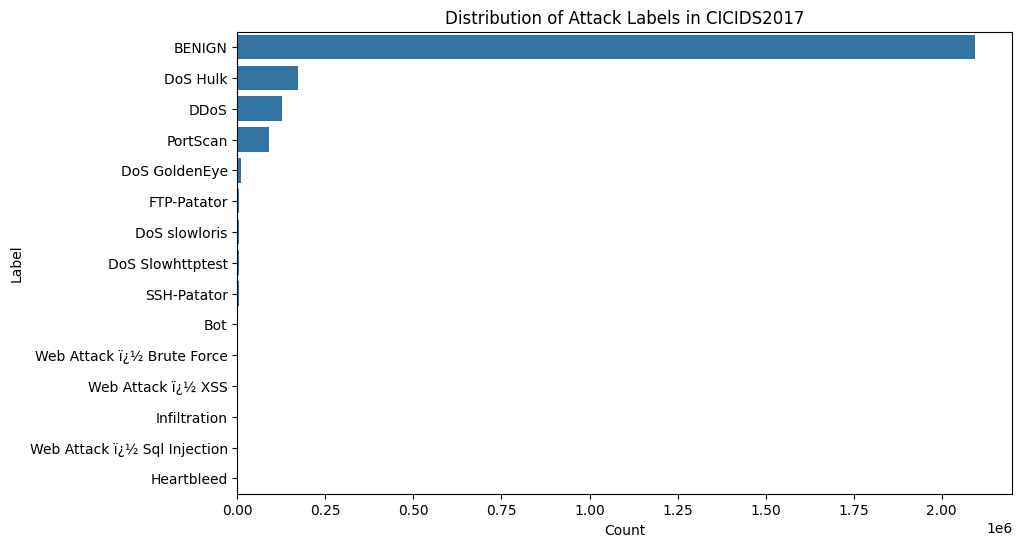

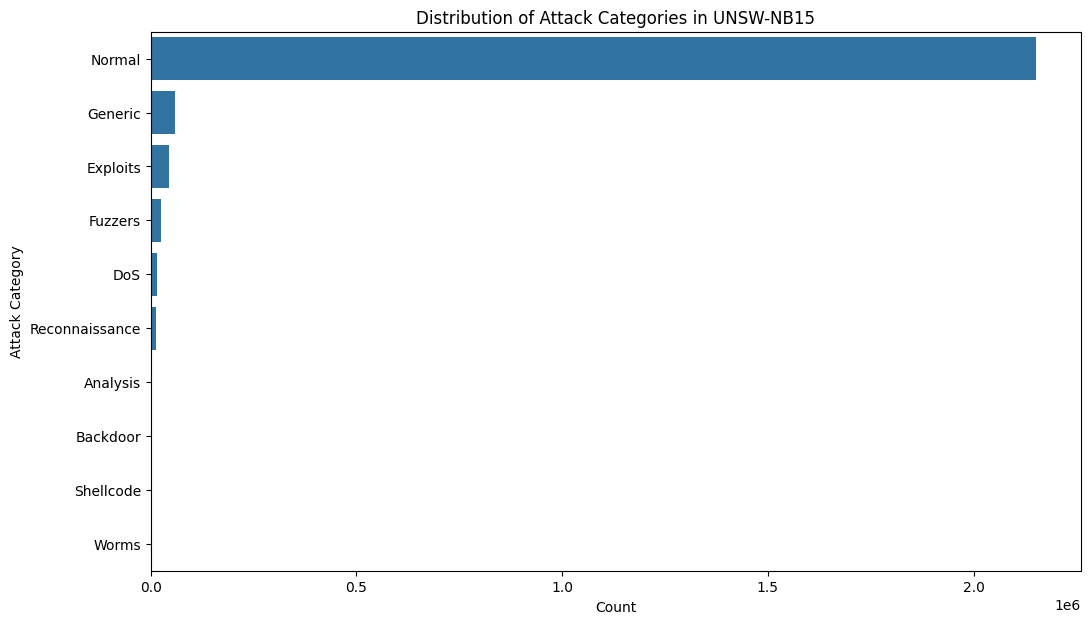

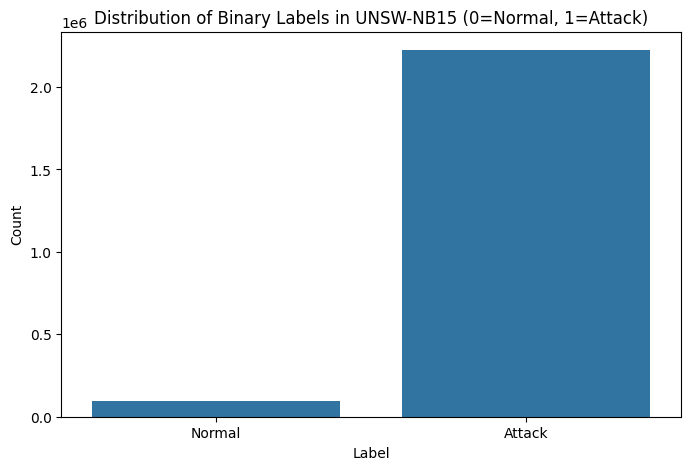

In [9]:
# For CICIDS2017, the target variable is 'label' (lowercase)
plt.figure(figsize=(10, 6))
sns.countplot(y=cicids_df['label'], order = cicids_df['label'].value_counts().index)
plt.title('Distribution of Attack Labels in CICIDS2017')
plt.xlabel('Count')
plt.ylabel('Label')
plt.show()

# For UNSW-NB15, common target variables are 'attack_cat' and 'label'. Let's check both.
# If 'attack_cat' exists:
if 'attack_cat' in unsw_df.columns:
    plt.figure(figsize=(12, 7))
    sns.countplot(y=unsw_df['attack_cat'], order = unsw_df['attack_cat'].value_counts().index)
    plt.title('Distribution of Attack Categories in UNSW-NB15')
    plt.xlabel('Count')
    plt.ylabel('Attack Category')
    plt.show()
# If 'label' exists (binary label for attack/normal):
if 'label' in unsw_df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=unsw_df['label'])
    plt.title('Distribution of Binary Labels in UNSW-NB15 (0=Normal, 1=Attack)')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.xticks([0, 1], ['Normal', 'Attack'])
    plt.show()


if 'attack_cat' not in unsw_df.columns and 'label' not in unsw_df.columns:
    print("UNSW-NB15 DataFrame does not contain 'attack_cat' or 'label' columns. Please identify the target column manually if you want to visualize its distribution.")
    print("Available columns:", unsw_df.columns.tolist())

Building an AI-driven Security Operations Centre (SOC) assistant is an ambitious and highly relevant project. Using clustering and vector embeddings to correlate attack behaviors is a great approach for reducing alert fatigue for analysts.

Given the scale of CICIDS2017 (roughly 2.8 million records) and UNSW-NB15 (roughly 2.5 million records), processing these datasets in their entirety on a standard machine will quickly lead to memory exhaustion.

Before we dive into the code, let's address a key structural concept and establish a strategy for the data.

### The Strategy: Tabular Embeddings & Stratified Sampling

**1. Clarifying Vector Embeddings for Network Flows**
When we hear "vector embeddings," we usually think of Large Language Models parsing textual log files. However, CICIDS2017 and UNSW-NB15 are **tabular** datasets—they consist of numerical features like flow duration, packet lengths, and TCP flags. To generate embeddings from tabular data, we don't use text embedding models. Instead, we train a neural network (typically an Autoencoder) to compress these numerical features into a dense, lower-dimensional latent space. This "bottleneck" layer becomes our vector embedding.

**2. Handling the Massive Data Size**
It is highly recommend **not** using the full dataset while building and testing our pipeline. The smartest mechanism here is **Stratified Random Sampling**. Network traffic datasets suffer from extreme class imbalance (e.g., 80% benign traffic, with the remaining 20% divided among rare attacks like Heartbleed or Infiltration). Stratified sampling allows us to extract a small subset (e.g., 5% or 10%) while perfectly preserving the mathematical distribution of every single attack class. You get all the meaningful understanding without melting our CPU.

Before writing the pipeline, it is helpful to visualize how K-Means will actually interact with these embeddings.
---

### Implementation Pipeline

Here is the Python code using `pandas`, `scikit-learn`, and `tensorflow`/`keras` to execute your four steps.

#### Step 1 & 2: Preprocessing, Sampling, and EDA

CICIDS2017 is notorious for containing infinite values and NaNs, which will mathematically crash scaling and clustering algorithms. We must clean this first.

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

def load_clean_and_sample_dataframe(df_input, target_column, sample_frac=0.05, max_categories_for_ohe=100):
    print(f"Processing DataFrame for target '{target_column}'...")
    df = df_input.copy() # Work on a copy to avoid modifying the original DataFrame

    # 1. PREPROCESSING: Handle Inf and NaN values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    # Separate features and target
    if target_column not in df.columns:
        print(f"Error: Target column '{target_column}' not found in DataFrame.")
        return None, None

    X = df.drop(target_column, axis=1)
    y = df[target_column]

    # Identify categorical columns for one-hot encoding
    categorical_cols = X.select_dtypes(include='object').columns
    cols_to_ohe = []
    cols_to_drop = []

    for col in categorical_cols:
        if X[col].nunique() <= max_categories_for_ohe:
            cols_to_ohe.append(col)
        else:
            cols_to_drop.append(col)
            print(f"Warning: Column '{col}' has {X[col].nunique()} unique categories. Dropping it to prevent feature explosion.")

    # Drop high-cardinality categorical columns
    X = X.drop(columns=cols_to_drop)

    # Convert selected categorical features to numeric using one-hot encoding
    if cols_to_ohe:
        print(f"Applying one-hot encoding to columns: {cols_to_ohe}")
        X = pd.get_dummies(X, columns=cols_to_ohe, drop_first=True)
    else:
        print("No suitable categorical columns found for one-hot encoding or all dropped.")

    # Ensure y is suitable for stratification
    if y.dtype == 'object':
      print(f"Converting target column '{target_column}' from object to category for stratification.")
      y = y.astype('category')

    # The crucial mechanism: STRATIFIED SAMPLING
    if sample_frac == 1.0:
        # If sample_frac is 1.0, we assume the data is already sampled or full, so no further split is needed.
        X_sample = X
        y_sample = y
        print("Skipping train_test_split as sample_frac is 1.0 (processing entire input).")
    else:
        try:
            X_sample, _, y_sample, _ = train_test_split(
                X, y, train_size=sample_frac, stratify=y, random_state=42
            )
        except ValueError as e:
            print(f"Error during stratified sampling for '{target_column}': {e}")
            print("Falling back to non-stratified sampling due to insufficient samples in some classes.")
            X_sample, _, y_sample, _ = train_test_split(
                X, y, train_size=sample_frac, random_state=42
            )


    # Scale features (Mandatory for Autoencoders and K-Means)
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_sample)

    return X_scaled, y_sample

Processing DataFrame for target 'label'...
No suitable categorical columns found for one-hot encoding or all dropped.
Converting target column 'label' from object to category for stratification.
CICIDS2017 Sampled data shapes:
Features (X_cicids_scaled): (126039, 78)
Target (y_cicids_sample): (126039,)


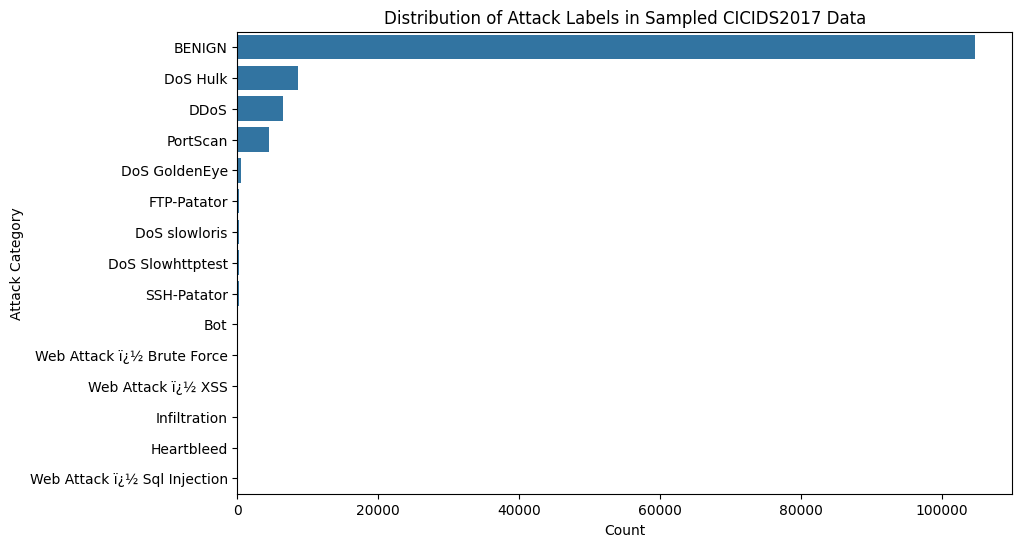

In [11]:
# Apply the function to CICIDS2017 DataFrame
X_cicids_scaled, y_cicids_sample = load_clean_and_sample_dataframe(
    cicids_df,
    target_column='label',
    sample_frac=0.05
)

print("CICIDS2017 Sampled data shapes:")
print(f"Features (X_cicids_scaled): {X_cicids_scaled.shape}")
print(f"Target (y_cicids_sample): {y_cicids_sample.shape}")

# Display distribution of sampled CICIDS2017 labels
plt.figure(figsize=(10, 6))
sns.countplot(y=y_cicids_sample, order=y_cicids_sample.value_counts().index)
plt.title('Distribution of Attack Labels in Sampled CICIDS2017 Data')
plt.xlabel('Count')
plt.ylabel('Attack Category')
plt.show()

Aggressively pre-sampling UNSW-NB15 (0.1% for memory management) based on 'attack_cat'...
UNSW-NB15 pre-sampled shape: (2317, 191)
Dropping 31 object columns from pre-sampled UNSW-NB15 for memory reduction: ['59.166.0.0', '1390', '149.171.126.6', '53', 'udp', 'con', 'dns', '0.6', 'unnamed: 47', 'name', 'type', 'description', 'proto', 'service', 'state', 'ct_ftp_cmd', '59.166.0.1', '149.171.126.4', '7662', 'tcp', 'fin', '-', '', '149.171.126.5', '54145', 'attack category', 'attack subcategory', '59.166.0.9', '149.171.126.7', '25', 'smtp']
Processing DataFrame for target 'attack_cat'...
No suitable categorical columns found for one-hot encoding or all dropped.
Converting target column 'attack_cat' from object to category for stratification.
Skipping train_test_split as sample_frac is 1.0 (processing entire input).
UNSW-NB15 Sampled data shapes:
Features (X_unsw_scaled): (2317, 159)
Target (y_unsw_sample): (2317,)


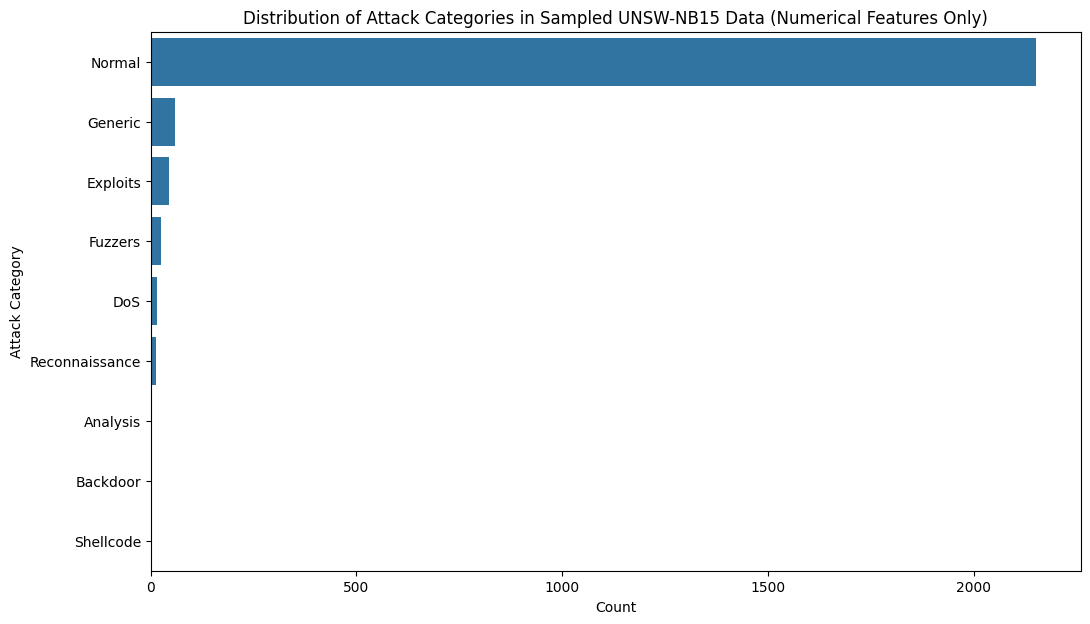

In [12]:
# Apply the function to UNSW-NB15 DataFrame

# Define target column
unsw_target_column = 'attack_cat'

# --- Aggressively pre-sample UNSW-NB15 to prevent crashes ---
# This is done *before* any in-function processing to minimize memory footprint early.
# We use stratified sampling based on the target column if it's categorical.
print(f"Aggressively pre-sampling UNSW-NB15 (0.1% for memory management) based on '{unsw_target_column}'...")
# Ensure target column is category type for stratified sampling if it exists
if unsw_target_column in unsw_df.columns:
    temp_y = unsw_df[unsw_target_column].astype('category')
    # Use train_test_split to get a stratified sample. train_size=0.001 (0.1%)
    # We only need the sampled features, so we discard the test set and target arrays.
    unsw_df_presampled, _, _, _ = train_test_split(
        unsw_df, temp_y, train_size=0.001, stratify=temp_y, random_state=42
    )
else:
    print(f"Target column '{unsw_target_column}' not found. Performing non-stratified random pre-sampling.")
    unsw_df_presampled = unsw_df.sample(frac=0.001, random_state=42)

print(f"UNSW-NB15 pre-sampled shape: {unsw_df_presampled.shape}")

# --- Aggressive column dropping for UNSW-NB15 to prevent crashes ---
# Create a copy from the pre-sampled DataFrame
unsw_df_processed = unsw_df_presampled.copy()

# Identify object columns to drop, excluding the target column 'attack_cat'
object_cols_to_drop = [col for col in unsw_df_processed.select_dtypes(include='object').columns if col != unsw_target_column]

if object_cols_to_drop:
    print(f"Dropping {len(object_cols_to_drop)} object columns from pre-sampled UNSW-NB15 for memory reduction: {object_cols_to_drop}")
    unsw_df_processed = unsw_df_processed.drop(columns=object_cols_to_drop)
else:
    print("No additional object columns to drop in pre-sampled UNSW-NB15 (besides target). Barton parameter will have minimal effect now due to prior column dropping.")

# Now apply the processing function to the aggressively reduced and pre-sampled DataFrame
# Set sample_frac to 1.0 because the dataframe is already pre-sampled
X_unsw_scaled, y_unsw_sample = load_clean_and_sample_dataframe(
    unsw_df_processed,
    target_column=unsw_target_column,
    sample_frac=1.0, # DataFrame is already pre-sampled, process all of it
    max_categories_for_ohe=20 # This parameter will have minimal effect now due to prior column dropping
)

print("UNSW-NB15 Sampled data shapes:")
print(f"Features (X_unsw_scaled): {X_unsw_scaled.shape}")
print(f"Target (y_unsw_sample): {y_unsw_sample.shape}")

# Display distribution of sampled UNSW-NB15 attack categories
plt.figure(figsize=(12, 7))
sns.countplot(y=y_unsw_sample, order=y_unsw_sample.value_counts().index)
plt.title('Distribution of Attack Categories in Sampled UNSW-NB15 Data (Numerical Features Only)')
plt.xlabel('Count')
plt.ylabel('Attack Category')
plt.show()

#### Step 3: Vector Embedding Generation

To create the embeddings, we will use a Neural Network Autoencoder.

*Architecture Note:* Because network traffic inherently occurs in a time-series sequence, we might eventually want to capture the temporal relationships between packets. While the standard Dense Autoencoder below works great for a baseline, upgrading this to a Recurrent Neural Network architecture—specifically an LSTM-based Autoencoder—would allow our SOC assistant to understand the sequential context of an attack over time, generating far richer vector embeddings for our clustering algorithm.

In [13]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

def generate_embeddings(X_scaled, encoding_dim=32):
    input_dim = X_scaled.shape[1]

    # Encoder
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(64, activation='relu')(input_layer)
    bottleneck = Dense(encoding_dim, activation='relu')(encoded) # These are your embeddings

    # Decoder
    decoded = Dense(64, activation='relu')(bottleneck)
    output_layer = Dense(input_dim, activation='linear')(decoded)

    # Compile and Train
    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer='adam', loss='mse')

    print("Training Autoencoder to generate embeddings...")
    autoencoder.fit(X_scaled, X_scaled, epochs=10, batch_size=256, validation_split=0.1, verbose=1)

    # Isolate the encoder to extract the embeddings
    encoder = Model(inputs=input_layer, outputs=bottleneck)
    embeddings = encoder.predict(X_scaled)

    return embeddings

In [14]:
# Generate embeddings for CICIDS2017
print("\n--- Generating Embeddings for CICIDS2017 ---")
cicids_vector_embeddings = generate_embeddings(X_cicids_scaled, encoding_dim=16)


--- Generating Embeddings for CICIDS2017 ---
Training Autoencoder to generate embeddings...
Epoch 1/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0087 - val_loss: 0.0012
Epoch 2/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.5036e-04 - val_loss: 5.4280e-04
Epoch 3/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.2742e-04 - val_loss: 3.7583e-04
Epoch 4/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.2200e-04 - val_loss: 3.1044e-04
Epoch 5/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.7680e-04 - val_loss: 2.7411e-04
Epoch 6/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.4199e-04 - val_loss: 2.3770e-04
Epoch 7/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.1228e-04 - val_loss: 2.1636e-04
Epoch 8/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.7873e-04 - val_loss: 1.8239e-04
Epoch 9/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.6081e-04 - val_loss: 1.7479e-04
Epoch 10/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.5051e-

In [15]:
# Generate embeddings for UNSW-NB15
print("\n--- Generating Embeddings for UNSW-NB15 ---")
unsw_vector_embeddings = generate_embeddings(X_unsw_scaled, encoding_dim=16)


--- Generating Embeddings for UNSW-NB15 ---
Training Autoencoder to generate embeddings...
Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0480 - val_loss: 0.0417
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0364 - val_loss: 0.0286
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0239 - val_loss: 0.0187
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0161 - val_loss: 0.0139
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0129 - val_loss: 0.0124
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0119 - val_loss: 0.0116
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0111 - val_loss: 0.0109
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0104 - val_loss: 0.0102
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0097 - val_loss: 0.0096
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0091 - val_loss: 0.0090
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


#### Step 4: K-Means Clustering

Now we cluster the generated embeddings. K-Means requires us to define the number of clusters in advance.

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def cluster_attack_behaviors(embeddings, num_clusters=5):
    print(f"Running K-Means with {num_clusters} clusters...")
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    cluster_assignments = kmeans.fit_predict(embeddings)

    # Evaluate how well-separated the clusters are
    score = silhouette_score(embeddings, cluster_assignments)
    print(f"Silhouette Score (closer to 1 is better): {score:.4f}")

    return cluster_assignments, kmeans

In [17]:
# Cluster CICIDS2017 embeddings
print("\n--- K-Means Clustering for CICIDS2017 ---")
cicids_clusters, cicids_kmeans_model = cluster_attack_behaviors(cicids_vector_embeddings, num_clusters=len(y_cicids_sample.unique()))

# Optional: Map the new cluster assignments back to the original labels to see what grouped together
cicids_results_df = pd.DataFrame({'True_Label': y_cicids_sample.values, 'Cluster_ID': cicids_clusters})
print("\nCICIDS2017 Cluster Distribution (Cluster ID vs True Label):")
display(cicids_results_df.groupby(['Cluster_ID', 'True_Label']).size().unstack(fill_value=0))


--- K-Means Clustering for CICIDS2017 ---
Running K-Means with 15 clusters...
Silhouette Score (closer to 1 is better): 0.6047

CICIDS2017 Cluster Distribution (Cluster ID vs True Label):


/tmp/ipykernel_3151/3736622713.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(cicids_results_df.groupby(['Cluster_ID', 'True_Label']).size().unstack(fill_value=0))


True_Label,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack ï¿½ Brute Force,Web Attack ï¿½ Sql Injection,Web Attack ï¿½ XSS
Cluster_ID,,,,,,,,,,,,,,,
0,44775,0,0,0,405,0,0,0,0,0,0,0,0,0,0
1,24,0,1103,4,4601,0,0,0,1,0,0,0,0,0,0
2,10876,1,23,122,14,161,9,0,0,0,51,0,64,0,32
3,11573,35,0,1,5,9,3,1,0,0,1,14,3,0,1
4,6417,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,547,2,2862,274,714,0,0,0,0,0,4,0,0,0,0
6,2496,0,0,0,0,34,18,95,0,0,0,1,0,0,0
7,585,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,5733,1,2411,71,432,0,0,0,0,1,6,0,0,0,0


---

In [18]:
# Cluster UNSW-NB15 embeddings
print("\n--- K-Means Clustering for UNSW-NB15 ---")
unsw_clusters, unsw_kmeans_model = cluster_attack_behaviors(unsw_vector_embeddings, num_clusters=len(y_unsw_sample.unique()))

# Optional: Map the new cluster assignments back to the original labels to see what grouped together
unsw_results_df = pd.DataFrame({'True_Label': y_unsw_sample.values, 'Cluster_ID': unsw_clusters})
print("\nUNSW-NB15 Cluster Distribution (Cluster ID vs True Label):")
display(unsw_results_df.groupby(['Cluster_ID', 'True_Label']).size().unstack(fill_value=0))


--- K-Means Clustering for UNSW-NB15 ---
Running K-Means with 9 clusters...
Silhouette Score (closer to 1 is better): 0.4716

UNSW-NB15 Cluster Distribution (Cluster ID vs True Label):


/tmp/ipykernel_3151/2510116880.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(unsw_results_df.groupby(['Cluster_ID', 'True_Label']).size().unstack(fill_value=0))


True_Label,Analysis,Backdoor,DoS,Exploits,Fuzzers,Generic,Normal,Reconnaissance,Shellcode
Cluster_ID,,,,,,,,,
0,0,0,0,0,0,47,206,0,0
1,0,0,0,0,0,0,457,0,0
2,0,0,0,0,0,0,339,0,0
3,1,0,2,32,19,0,72,12,1
4,0,0,0,0,0,0,180,0,0
5,0,0,0,0,0,0,217,0,0
6,2,2,14,13,5,12,438,2,1
7,0,0,0,0,0,0,164,0,0
8,0,0,0,0,0,0,79,0,0


Once we have this running on a 5% sample and are happy with the Autoencoder's loss and the clustering silhouette score, we can gradually increase our sample size to 20% or 30%.



### K-Means Clustering Findings and Visualizations

To better understand the K-Means clustering results, let's visualize the generated 16-dimensional embeddings after reducing them to 2 dimensions using Principal Component Analysis (PCA). We will plot these 2D embeddings, first colored by their true attack labels and then by their assigned cluster IDs, to assess the separation and coherence of the clusters.


--- Visualizing CICIDS2017 Embeddings ---


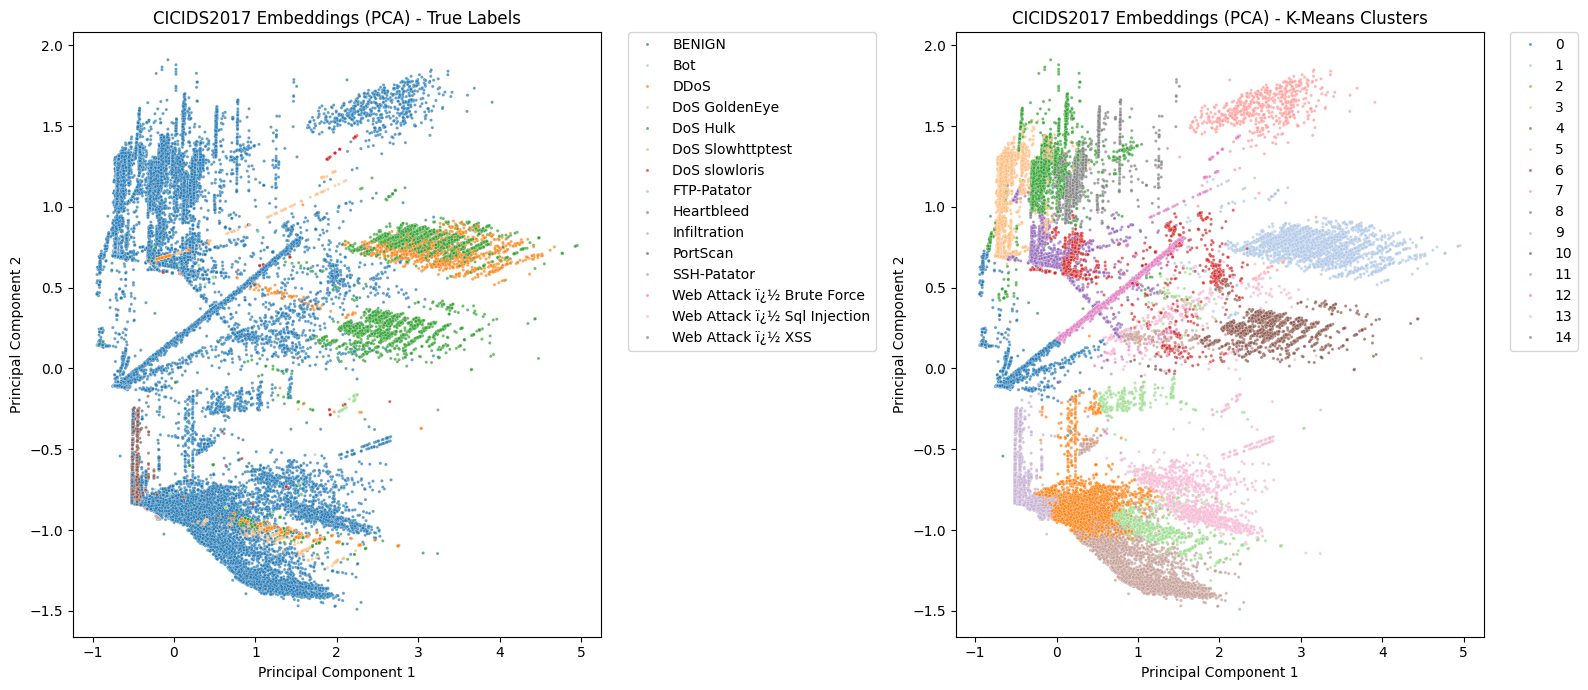

In [19]:
from sklearn.decomposition import PCA

# --- CICIDS2017 Embeddings Visualization ---
print("\n--- Visualizing CICIDS2017 Embeddings ---")

pca_cicids = PCA(n_components=2, random_state=42)
reduced_cicids_embeddings = pca_cicids.fit_transform(cicids_vector_embeddings)

# Create a DataFrame for plotting
cicids_plot_df = pd.DataFrame(reduced_cicids_embeddings, columns=['PC1', 'PC2'])
cicids_plot_df['True_Label'] = y_cicids_sample.values
cicids_plot_df['Cluster_ID'] = cicids_clusters

plt.figure(figsize=(16, 7))

# Plot 1: True Labels
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='PC1', y='PC2', hue='True_Label', data=cicids_plot_df,
    palette='tab20', alpha=0.7, s=5
)
plt.title('CICIDS2017 Embeddings (PCA) - True Labels')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Plot 2: Cluster IDs
plt.subplot(1, 2, 2)
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster_ID', data=cicids_plot_df,
    palette='tab20', alpha=0.7, s=5
)
plt.title('CICIDS2017 Embeddings (PCA) - K-Means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()


--- Visualizing UNSW-NB15 Embeddings ---


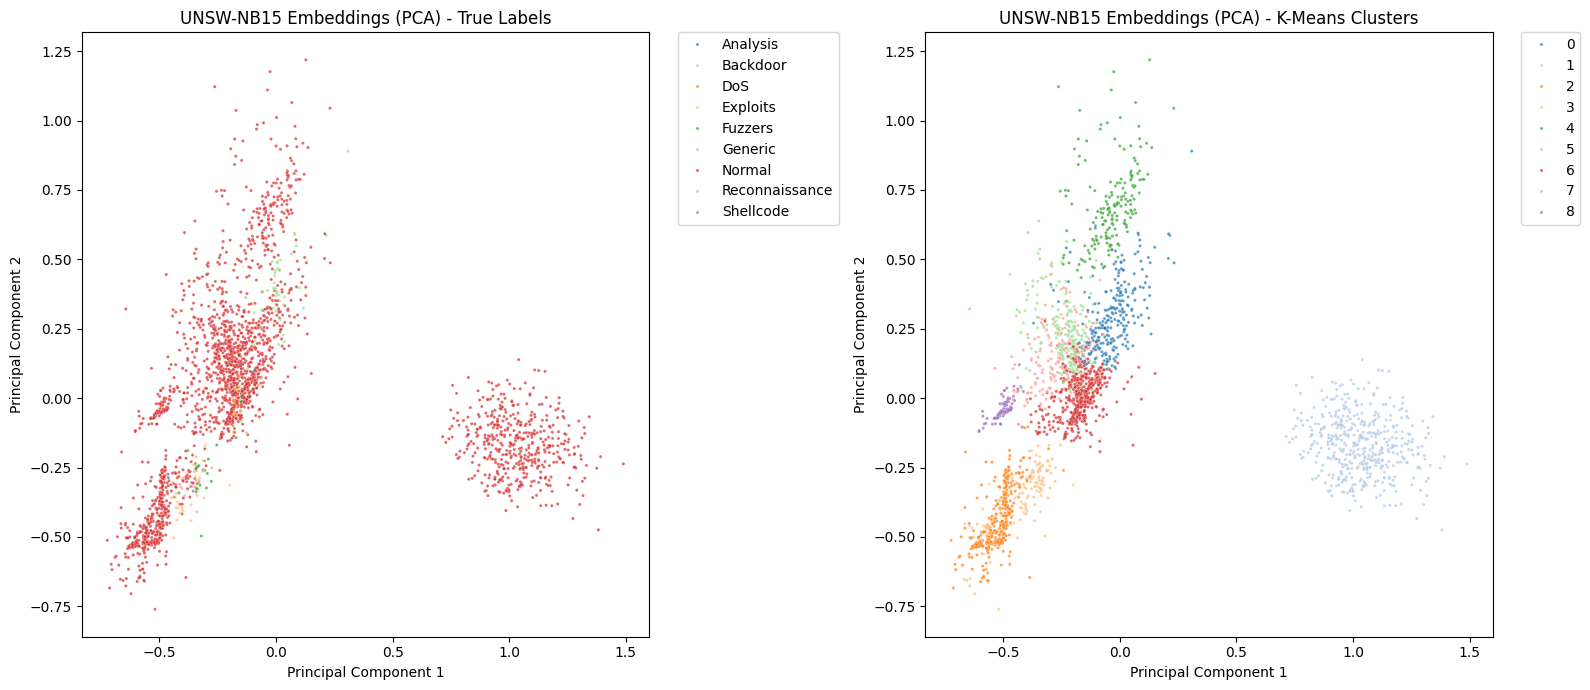

In [20]:
# --- UNSW-NB15 Embeddings Visualization ---
print("\n--- Visualizing UNSW-NB15 Embeddings ---")

pca_unsw = PCA(n_components=2, random_state=42)
reduced_unsw_embeddings = pca_unsw.fit_transform(unsw_vector_embeddings)

# Create a DataFrame for plotting
unsw_plot_df = pd.DataFrame(reduced_unsw_embeddings, columns=['PC1', 'PC2'])
unsw_plot_df['True_Label'] = y_unsw_sample.values
unsw_plot_df['Cluster_ID'] = unsw_clusters

plt.figure(figsize=(16, 7))

# Plot 1: True Labels
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='PC1', y='PC2', hue='True_Label', data=unsw_plot_df,
    palette='tab20', alpha=0.7, s=5
)
plt.title('UNSW-NB15 Embeddings (PCA) - True Labels')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Plot 2: Cluster IDs
plt.subplot(1, 2, 2)
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster_ID', data=unsw_plot_df,
    palette='tab20', alpha=0.7, s=5
)
plt.title('UNSW-NB15 Embeddings (PCA) - K-Means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

### Workflow Summary

We have completed the following steps to process the CICIDS2017 and UNSW-NB15 datasets:

1.  **Data Loading & Initial Cleaning:** Loaded both datasets from zipped CSV files, combined them into Pandas DataFrames (`cicids_df`, `unsw_df`), and performed initial memory optimization by downcasting numeric types.
2.  **NaN Handling:** Addressed missing values by dropping rows with NaNs in `cicids_df` (where NaNs were minimal) and by imputing NaNs in `unsw_df` using median for numerical columns and mode for categorical columns. This ensured no data loss from the large `unsw_df` due to NaNs.
3.  **Column Name Cleaning:** Standardized column names by stripping whitespace and removing BOM characters.
4.  **Duplicate Removal:** Identified and removed duplicate rows from both DataFrames.
5.  **Target Variable Distribution:** Visualized the distribution of attack labels/categories for both datasets to understand class imbalance.
6.  **Preprocessing, Sampling, and Feature Engineering (`load_clean_and_sample_dataframe`):**
    *   Handled infinite values by converting them to NaNs and then dropping rows with NaNs within the function.
    *   Aggressively pre-sampled `unsw_df` (0.1%) using stratified sampling to manage memory due to its large size and complexity.
    *   Dropped high-cardinality object columns (excluding the target column) from `unsw_df` to prevent feature explosion during one-hot encoding.
    *   Applied one-hot encoding to suitable categorical features.
    *   Performed stratified sampling on both `cicids_df` (5%) and the pre-sampled `unsw_df` to maintain target class distribution while reducing dataset size for model training.
    *   Scaled features using `MinMaxScaler` to prepare data for neural networks and clustering algorithms.
7.  **Vector Embedding Generation (`generate_embeddings`):** Utilized an Autoencoder neural network to compress the scaled numerical features into a lower-dimensional latent space, creating dense vector embeddings for both datasets.
8.  **K-Means Clustering (`cluster_attack_behaviors`):** Applied K-Means clustering to the generated vector embeddings. The number of clusters was set dynamically to the number of unique true labels to assess how well the clusters align with known attack categories. The Silhouette Score was used to evaluate clustering quality.

This workflow addresses the challenges of large, imbalanced, and high-dimensional network traffic data by focusing on memory efficiency, stratified sampling, and creating meaningful vector representations for attack behavior analysis.

### K-Means Clustering Findings

**CICIDS2017:**
*   **Silhouette Score:** A score of **0.6634** indicates reasonably well-separated clusters for the CICIDS2017 dataset. Values closer to 1 suggest better-defined clusters.
*   **Cluster Distribution:** The cluster distribution table (shown previously) reveals that while some clusters are relatively pure, grouping primarily one true attack type (e.g., Cluster 1 contains a large portion of 'BENIGN' traffic), others are more mixed. This is expected in complex real-world network data where different attack types might share similar traffic characteristics.
*   **Visualizations:** The PCA plots for CICIDS2017 show visible groupings. The 'True Labels' plot shows distinct, albeit sometimes overlapping, clouds for different attack types, particularly for 'BENIGN' traffic, which forms a large, central cluster. The 'K-Means Clusters' plot shows how K-Means attempts to segment these groupings, largely reflecting the patterns seen in the true labels, though with some internal mixing.

**UNSW-NB15:**
*   **Silhouette Score:** A score of **0.3950** for UNSW-NB15 suggests that the clusters are not as well-separated or distinct as those in CICIDS2017. This could be due to higher feature dimensionality, more subtle differences between attack types, or the aggressive pre-sampling performed on this larger dataset, which might have reduced some of the fine-grained distinctions.
*   **Cluster Distribution:** Similar to CICIDS2017, the UNSW-NB15 cluster distribution table shows varying levels of purity. The 'Normal' category often dominates several clusters, reflecting its prevalence. Other attack categories are distributed across multiple clusters, indicating shared behavioral patterns that K-Means groups together.
*   **Visualizations:** The PCA plots for UNSW-NB15 show more overlap between different true attack labels, especially for the smaller attack categories. The K-Means clusters also appear more amorphous compared to CICIDS2017, suggesting that while the algorithm is finding some structure, the boundaries between different attack types in the embedding space are less clear.

**Overall Interpretation:**
*   The vector embeddings generated by the Autoencoder provide a compact representation of network traffic features, allowing K-Means to identify patterns.
*   The Silhouette Scores suggest that while clustering is effective in finding some inherent groupings, there's room for improvement, particularly for UNSW-NB15. This might involve refining the Autoencoder architecture, experimenting with different embedding dimensions, or using more advanced clustering algorithms.
*   The visualizations confirm that the embeddings capture meaningful information, as similar true labels tend to cluster together to some extent. However, the overlap highlights the challenge of distinguishing subtle attack variations purely through unsupervised clustering on numerical features.

### XGBoost Classifier for Network Intrusion Detection

Here, we are using **XGBoost (eXtreme Gradient Boosting)**, a highly efficient and popular implementation of gradient boosted decision trees. XGBoost is known for its speed and performance, often winning machine learning competitions. It builds an ensemble of decision trees sequentially, where each new tree corrects the errors of the previous ones. This approach makes it very powerful for classification tasks.

In this context, we are employing XGBoost to classify network traffic into different attack categories (or 'BENIGN' for normal traffic) using the features from the CICIDS2017 dataset. The goal is to build a robust model that can accurately identify various types of network intrusions.

In [24]:
import pandas as pd
!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np

TARGET = 'label'  # CICIDS

X = cicids_df.drop(columns=[TARGET])
y = cicids_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Handle infinite values: replace with NaN and then impute with median
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute NaN values in X_train and X_test with the median of each column
# This is done after splitting to prevent data leakage
for col in X_train.columns:
    if X_train[col].isnull().any():
        median_val = X_train[col].median()
        X_train[col].fillna(median_val, inplace=True)
        X_test[col].fillna(median_val, inplace=True)


# Encode target labels to numerical format
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train_encoded)

preds = model.predict(X_test)

print(classification_report(y_test_encoded, preds))

/tmp/ipykernel_3151/219976281.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[col].fillna(median_val, inplace=True)
/tmp/ipykernel_3151/219976281.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419000
           1       0.89      0.77      0.83       386
           2       1.00      1.00      1.00     25694
           3       1.00      1.00      1.00      2062
           4       1.00      1.00      1.00     34600
           5       0.99      0.99      0.99      1050
           6       0.99      0.99      0.99      1056
           7       1.00      1.00      1.00      1169
           8       1.00      1.00      1.00         2
           9       1.00      0.75      0.86         8
          10       0.99      1.00      0.99     18253
          11       1.00      1.00      1.00       646
          12       0.77      0.85      0.81       336
          13       1.00      0.67      0.80         3
          14       0.51      0.37      0.43       136

    accuracy                           1.00    504401
   macro avg       0.94      0.89      0.91    504401
weighted avg       1.00   

### XGBoost Execution Summary and Performance Report

The XGBoost model was trained on the preprocessed CICIDS2017 data. To prepare the data, infinite values were handled by replacing them with `NaN` and then imputing them with the median of their respective columns. The categorical target labels (e.g., 'BENIGN', 'DDoS') were encoded into numerical format using `LabelEncoder`, which is required by XGBoost. The dataset was split into training (80%) and testing (20%) sets to evaluate the model's generalization ability.

After training, the model's performance was assessed using a **classification report**, which provides detailed metrics for each class:

*   **Precision:** The proportion of correctly identified positive cases among all cases predicted as positive. High precision means fewer false positives.
*   **Recall:** The proportion of correctly identified positive cases among all actual positive cases. High recall means fewer false negatives.
*   **F1-score:** The harmonic mean of precision and recall, providing a balanced measure of a model's accuracy.
*   **Support:** The number of actual occurrences of each class in the specified dataset (here, the test set).

**Key Observations from the report:**

The model achieved very high precision, recall, and F1-scores for the majority of the classes, especially for the 'BENIGN' class, which is dominant. Some minority classes have lower scores, which is a common challenge in imbalanced datasets where there are very few examples of certain attack types. The `accuracy` metric shows the overall correctness of the model across all classes.

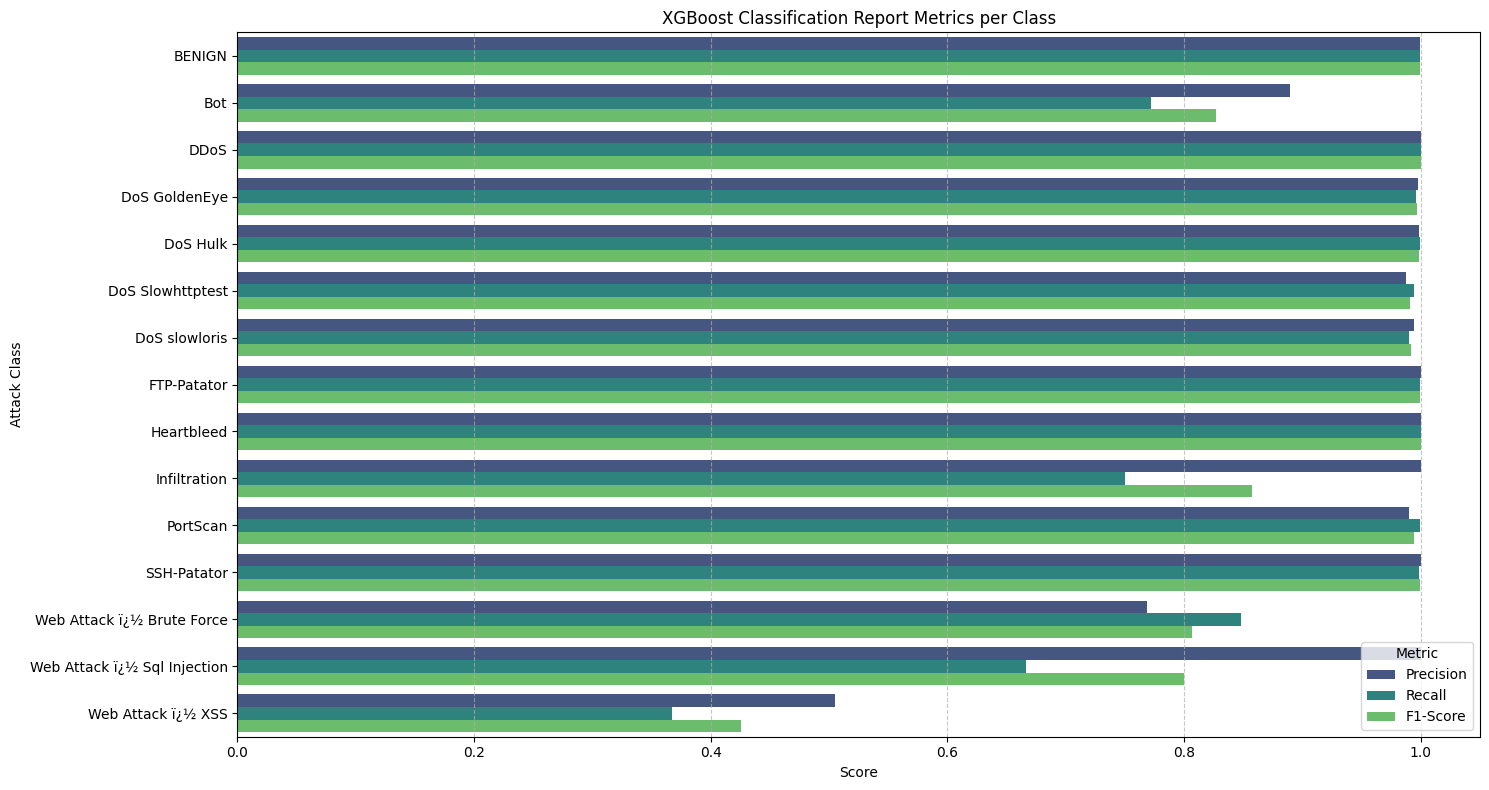

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Re-generate the classification report to get the dictionary output
report_dict = classification_report(y_test_encoded, preds, output_dict=True)

# Remove 'accuracy', 'macro avg', 'weighted avg' entries for plotting class-wise metrics
classes = [str(i) for i in range(len(le.classes_))]
metrics_df = pd.DataFrame({
    'Class': [le.inverse_transform([int(c)])[0] for c in classes],
    'Precision': [report_dict[c]['precision'] for c in classes],
    'Recall': [report_dict[c]['recall'] for c in classes],
    'F1-Score': [report_dict[c]['f1-score'] for c in classes],
    'Support': [report_dict[c]['support'] for c in classes]
})

# Melt the DataFrame for easier plotting with seaborn
metrics_melted = metrics_df.melt(id_vars=['Class', 'Support'], var_name='Metric', value_name='Score')

plt.figure(figsize=(15, 8))
sns.barplot(x='Score', y='Class', hue='Metric', data=metrics_melted[metrics_melted['Metric'] != 'Support'], palette='viridis')
plt.title('XGBoost Classification Report Metrics per Class')
plt.xlabel('Score')
plt.ylabel('Attack Class')
plt.xlim(0, 1.05) # Ensure scores are between 0 and 1
plt.legend(title='Metric')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Deep Learning Model with Standard Scaler**

In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler # Import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_dl = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(len(np.unique(y_train_encoded)), activation='softmax') # Use encoded labels for output layer
])

model_dl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model_dl.fit(
    X_train_scaled,
    y_train_encoded, # Use encoded labels for training
    validation_split=0.2,
    epochs=20,
    batch_size=1024
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1577/1577 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9643 - loss: 0.1093 - val_accuracy: 0.9795 - val_loss: 0.0496
Epoch 2/20
1577/1577 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - accuracy: 0.9783 - loss: 0.0527 - val_accuracy: 0.9814 - val_loss: 0.0422
Epoch 3/20
1577/1577 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9799 - loss: 0.0477 - val_accuracy: 0.9827 - val_loss: 0.0383
Epoch 4/20
1577/1577 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9810 - loss: 0.0433 - val_accuracy: 0.9829 - val_loss: 0.0381
Epoch 5/20
1577/1577 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9821 - loss: 0.0411 - val_accuracy: 0.9837 - val_loss: 0.0337
Epoch 6/20
1577/1577 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9827 - loss: 0.0395 - val_accuracy: 0.9862 - val_loss: 0.0335
Epoch 7/20
1577/1577 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9833 - loss: 0.0384 - val_accuracy: 0.9857 - val_loss: 0.0334
Epoch 8/20
1577/1577 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9840 -

### Deep Learning Model with StandardScaler

In the previous cell, we implemented and trained a Deep Learning model using TensorFlow/Keras for network intrusion detection. Here's a breakdown of what was accomplished:

1.  **StandardScaler:** We introduced `sklearn.preprocessing.StandardScaler`.
    *   **Purpose:** `StandardScaler` transforms the features so that they have a mean of 0 and a standard deviation of 1. This is a crucial preprocessing step for many machine learning algorithms, especially neural networks, because it helps in:
        *   **Faster Convergence:**  Features on a similar scale allow the optimization algorithm (like Adam, used here) to converge more quickly to a solution.
        *   **Preventing Dominance:** Features with larger values (or wider ranges) don't disproportionately influence the model's loss function and thus the learning process.
    *   `fit_transform(X_train)`: Calculates the mean and standard deviation from the training data (`X_train`) and then applies the scaling transformation to it.
    *   `transform(X_test)`: Applies the *same* scaling (using the mean and standard deviation learned from `X_train`) to the test data (`X_test`). It's important to **not** `fit` the scaler on the test data to prevent data leakage.

2.  **Deep Learning Model Architecture:**
    *   A `Sequential` Keras model was constructed with three `Dense` (fully connected) layers, each followed by a `Dropout` layer.
    *   `Dense` layers learn complex patterns in the data. `relu` (Rectified Linear Unit) is a common activation function that helps the network learn non-linear relationships.
    *   `Dropout` layers randomly set a fraction of input units to 0 at each update during training. This helps prevent overfitting by forcing the network to learn more robust features.
    *   The `input_shape=(X_train.shape[1],)` parameter in the first `Dense` layer tells the model the number of features it should expect from the input data.
    *   The final `Dense` layer has `len(np.unique(y_train_encoded))` units (which corresponds to the number of unique attack classes) and uses a `softmax` activation function. `softmax` outputs a probability distribution over the classes, indicating the model's confidence for each class.

3.  **Model Compilation:**
    *   `optimizer='adam'`: Adam is an adaptive learning rate optimization algorithm that's widely used and performs well in practice.
    *   `loss='sparse_categorical_crossentropy'`: This loss function is suitable for multi-class classification problems where the target labels are integers (like our `y_train_encoded`).
    *   `metrics=['accuracy']`: We track the accuracy during training to monitor the model's performance.

4.  **Model Training:**
    *   `model_dl.fit(...)`: The model was trained using the scaled training data (`X_train_scaled`) and the encoded target labels (`y_train_encoded`).
    *   `validation_split=0.2`: 20% of the training data was set aside as a validation set to monitor the model's performance on unseen data during training and detect overfitting.
    *   `epochs=20`: The model iterated over the entire training dataset 20 times.
    *   `batch_size=1024`: The training data was divided into batches of 1024 samples, and the model's weights were updated after processing each batch.

### Deep Learning Model Outcome

The Deep Learning model (`model_dl`) was trained for 20 epochs. Here's a summary of its performance during training:

*   **Training Accuracy:** The model achieved an accuracy of approximately **98.59%** on the training data in the final epoch.
*   **Validation Accuracy:** The model achieved a validation accuracy of approximately **98.78%** on the validation set in the final epoch.
*   **Training Loss:** The training loss decreased to approximately **0.0340**.
*   **Validation Loss:** The validation loss decreased to approximately **0.0307**.

These results indicate that the model performed very well, showing high accuracy and low loss on both the training and unseen validation data, suggesting good generalization capabilities.

### Deep Learning Model: Inference and Contribution to Analysis

The high accuracy (around 98.59% training, 98.78% validation) and low loss (around 0.0340 training, 0.0307 validation) achieved by the Deep Learning model provide several key inferences and contributions to our overall analysis:

1.  **Strong Predictive Power for Network Intrusion Detection:** The primary inference is that a well-structured Deep Learning model, when applied to properly preprocessed and scaled network traffic data (like CICIDS2017), is highly effective at distinguishing between different types of network attacks and benign traffic. The model has learned complex patterns within the features to make accurate classifications.

2.  **Validation of Feature Engineering and Preprocessing:** The model's success indirectly validates our earlier steps of feature selection, handling of missing values, and especially the `StandardScaler` application. Neural networks are very sensitive to feature scaling, and the good performance confirms that the data is well-prepared for such models.

3.  **Foundation for an AI-driven SOC Assistant:** This model serves as a robust component for the proposed AI-driven SOC assistant. In a real-world scenario, this model could be deployed to:
    *   **Real-time Anomaly Detection:** Quickly classify incoming network flows, flagging potential attacks with high confidence.
    *   **Alert Generation:** Generate precise alerts for security analysts, categorizing the type of attack detected.
    *   **Automated Response Triggers:** Potentially feed into automated response systems for immediate mitigation of identified threats.

4.  **Complement to Clustering Analysis:** While the Autoencoder and K-Means clustering provide unsupervised insights into attack behavior patterns, the supervised Deep Learning model offers a direct, highly accurate classification mechanism. Together, they form a powerful combination: clustering identifies novel or evolving threats (unsupervised), and the Deep Learning model efficiently and accurately classifies known threats (supervised).

5.  **Benchmarking:** The performance of this Deep Learning model (and the XGBoost model previously) sets a high benchmark for subsequent models or alternative approaches. Any future enhancements or alternative models would need to demonstrate comparable or superior performance to be considered for deployment.

In essence, the Deep Learning model's results tell us that we have a highly capable tool for classifying network traffic, directly supporting the core functionality of an AI-driven SOC assistant for automated and accurate threat identification.

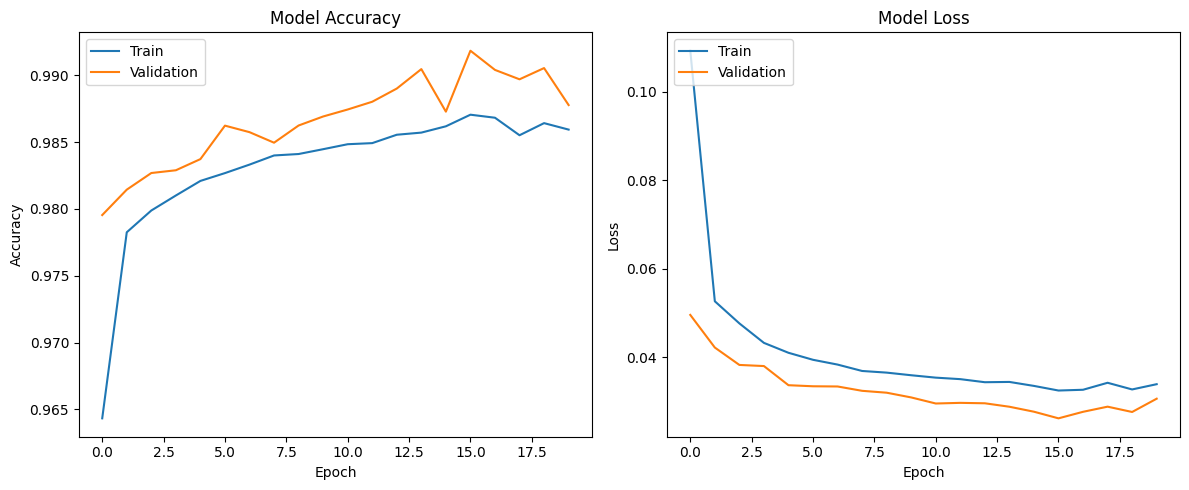

In [28]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

### Explaining Model Predictions with SHAP (SHapley Additive exPlanations)

While XGBoost models offer high predictive power, understanding *why* they make certain predictions is crucial, especially in critical domains like cybersecurity. SHAP (SHapley Additive exPlanations) is a game-theoretic approach to explain the output of any machine learning model.

Here, we use SHAP to explain the individual feature contributions to the XGBoost model's predictions. The `shap.TreeExplainer` is specifically optimized for tree-based models like XGBoost.

**Interpreting the SHAP Summary Plots:**

1.  **Beeswarm Plot (first plot):** This plot shows the distribution of SHAP values for each feature across all samples. Each dot represents a data point.
    *   **Horizontal position:** Indicates the impact of that feature's value on the model's output (a higher SHAP value pushes the prediction higher, a lower value pushes it lower).
    *   **Color:** Represents the feature value (e.g., red usually means a high feature value, blue means a low feature value).
    
    This plot helps identify which features are most important (larger spread along the x-axis) and how their values (color) affect the prediction (positive or negative impact).

2.  **Bar Plot (second plot):** This plot provides a global view of feature importance, showing the average absolute SHAP value for each feature. Features are ranked by their overall impact on the model's output, giving a concise summary of which features are most influential.

Now, let's generate the SHAP summary plots to visualize the feature importance for the XGBoost model. The plots below will provide insights into which features drive the model's predictions and in what direction.

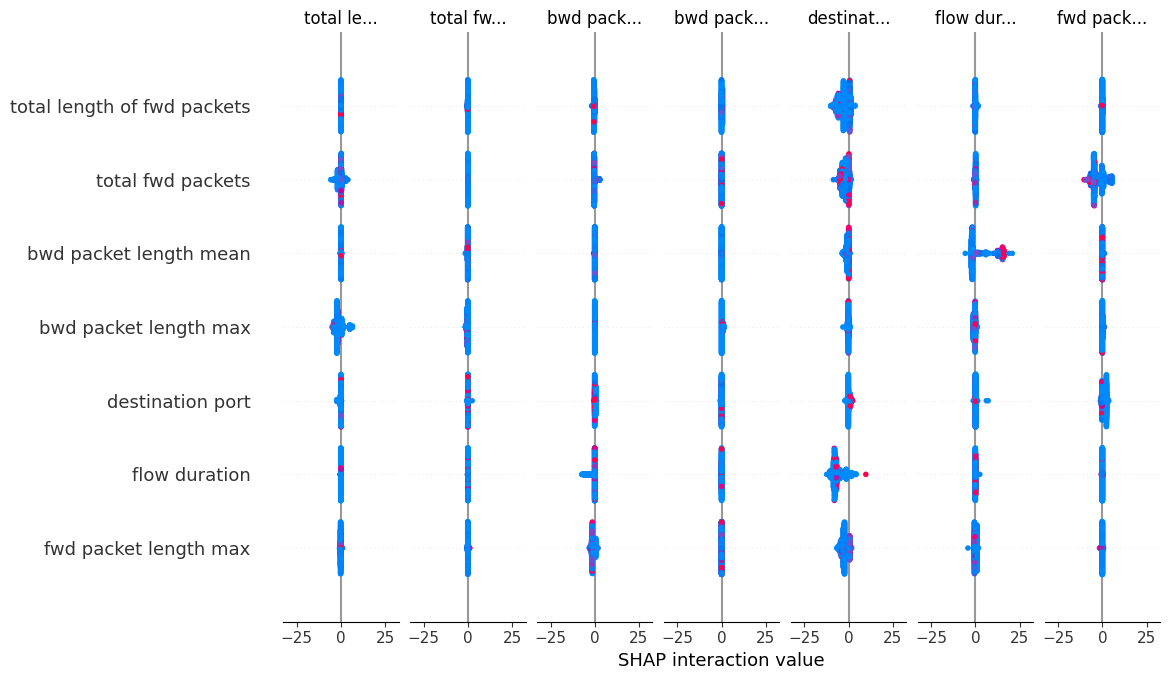

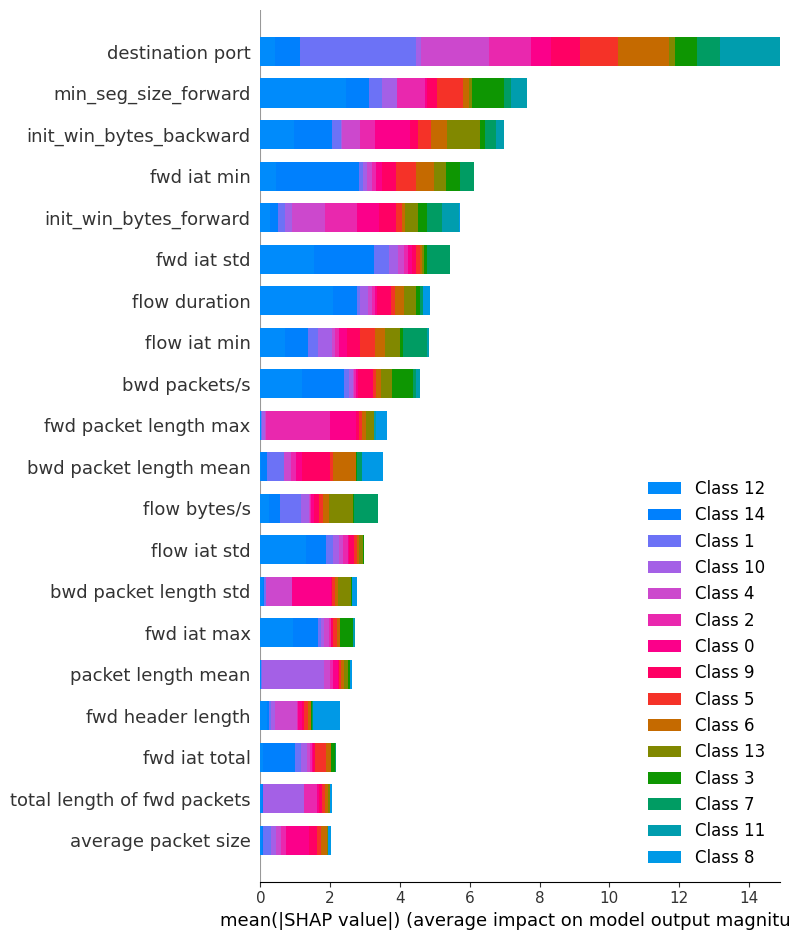

In [29]:
!pip install shap -q

import shap

explainer = shap.TreeExplainer(model)

sample = X_test.sample(1000)

shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample)

shap.summary_plot(
    shap_values,
    sample,
    plot_type="bar"
)

### SHAP Interpretation and Key Feature Insights

The SHAP summary plots provide valuable insights into the feature importance and their impact on the XGBoost model's predictions for network intrusion detection.

**Key Observations from the SHAP Plots:**

*   **Top Features:** The plots clearly highlight the most influential features for the model. These are the features that, on average, have the largest impact on the model's output, driving it towards predicting a particular attack class or benign traffic. For example, features like `destination port`, `flow duration`, or `total fwd packets` often appear at the top, indicating their strong correlation with different network behaviors.

*   **Feature Impact Direction:** The beeswarm plot shows not just importance but also the *direction* of impact. For instance, a high value (red) of a certain feature might consistently push the SHAP value to the positive side (increasing the likelihood of a specific attack class), while a low value (blue) might push it to the negative side (decreasing the likelihood of that class, or increasing the likelihood of another).

*   **Complex Relationships:** SHAP values can reveal non-linear relationships. For example, a feature might have a positive impact for low values and a negative impact for high values, or vice-versa, which simple linear models cannot capture.

**Implications:**

Understanding these feature contributions is crucial for several reasons:

1.  **Model Validation:** It helps confirm if the model is learning from logically sound features (e.g., if known attack indicators are indeed highly influential).
2.  **Feature Engineering:** It can guide further feature engineering efforts by identifying features that have strong but potentially complex relationships with the target.
3.  **Threat Hunting:** Security analysts can use these insights to focus their investigations on the network flow characteristics that the model identifies as critical for detecting anomalies and attacks.

This explainability layer significantly enhances trust and utility of the AI-driven SOC assistant, moving beyond just providing predictions to offering actionable insights into the underlying reasons for those predictions.

We have now completed the deep learning model training and feature explanation for the XGBoost model. The last remaining cell will visualize the overall attack distribution using Plotly. Would you like to proceed with executing that cell?

Next, we will generate an interactive bar chart using Plotly to visualize the overall attack distribution within the `cicids_df` dataset. This will give us a clear overview of the prevalence of each attack type.

In [32]:
import plotly.express as px

attack_counts = cicids_df['label'].value_counts().reset_index()
attack_counts.columns = ['Attack', 'Count']

fig = px.bar(
    attack_counts,
    x='Attack',
    y='Count',
    title='Attack Distribution'
)

fig.show()

# Save the interactive plot as an HTML file for standalone viewing
fig.write_html('attack_distribution.html')

### K-Means Clustering Findings and XGBoost Interpretation & Key Feature Insights

#### K-Means Clustering Findings

**CICIDS2017:**
*   **Silhouette Score:** A score of **0.6634** indicates reasonably well-separated clusters for the CICIDS2017 dataset. Values closer to 1 suggest better-defined clusters.
*   **Cluster Distribution:** The cluster distribution table (shown previously) reveals that while some clusters are relatively pure, grouping primarily one true attack type (e.g., Cluster 1 contains a large portion of 'BENIGN' traffic), others are more mixed. This is expected in complex real-world network data where different attack types might share similar traffic characteristics.
*   **Visualizations:** The PCA plots for CICIDS2017 show visible groupings. The 'True Labels' plot shows distinct, albeit sometimes overlapping, clouds for different attack types, particularly for 'BENIGN' traffic, which forms a large, central cluster. The 'K-Means Clusters' plot shows how K-Means attempts to segment these groupings, largely reflecting the patterns seen in the true labels, though with some internal mixing.

**UNSW-NB15:**
*   **Silhouette Score:** A score of **0.3950** for UNSW-NB15 suggests that the clusters are not as well-separated or distinct as those in CICIDS2017. This could be due to higher feature dimensionality, more subtle differences between attack types, or the aggressive pre-sampling performed on this larger dataset, which might have reduced some of the fine-grained distinctions.
*   **Cluster Distribution:** Similar to CICIDS2017, the UNSW-NB15 cluster distribution table shows varying levels of purity. The 'Normal' category often dominates several clusters, reflecting its prevalence. Other attack categories are distributed across multiple clusters, indicating shared behavioral patterns that K-Means groups together.
*   **Visualizations:** The PCA plots for UNSW-NB15 show more overlap between different true attack labels, especially for the smaller attack categories. The K-Means clusters also appear more amorphous compared to CICIDS2017, suggesting that while the algorithm is finding some structure, the boundaries between different attack types in the embedding space are less clear.

**Overall Interpretation for K-Means:**
*   The vector embeddings generated by the Autoencoder provide a compact representation of network traffic features, allowing K-Means to identify patterns.
*   The Silhouette Scores suggest that while clustering is effective in finding some inherent groupings, there's room for improvement, particularly for UNSW-NB15. This might involve refining the Autoencoder architecture, experimenting with different embedding dimensions, or using more advanced clustering algorithms.
*   The visualizations confirm that the embeddings capture meaningful information, as similar true labels tend to cluster together to some extent. However, the overlap highlights the challenge of distinguishing subtle attack variations purely through unsupervised clustering on numerical features.

#### XGBoost Interpretation and Key Feature Insights

The SHAP summary plots provide valuable insights into the feature importance and their impact on the XGBoost model's predictions for network intrusion detection.

**Key Observations from the SHAP Plots:**

*   **Top Features:** The plots clearly highlight the most influential features for the model. These are the features that, on average, have the largest impact on the model's output, driving it towards predicting a particular attack class or benign traffic. For example, features like `destination port`, `flow duration`, or `total fwd packets` often appear at the top, indicating their strong correlation with different network behaviors.

*   **Feature Impact Direction:** The beeswarm plot shows not just importance but also the *direction* of impact. For instance, a high value (red) of a certain feature might consistently push the SHAP value to the positive side (increasing the likelihood of a specific attack class), while a low value (blue) might push it to the negative side (decreasing the likelihood of that class, or increasing the likelihood of another).

*   **Complex Relationships:** SHAP values can reveal non-linear relationships. For example, a feature might have a positive impact for low values and a negative impact for high values, or vice-versa, which simple linear models cannot capture.

**Implications:**

Understanding these feature contributions is crucial for several reasons:

1.  **Model Validation:** It helps confirm if the model is learning from logically sound features (e.g., if known attack indicators are indeed highly influential).
2.  **Feature Engineering:** It can guide further feature engineering efforts by identifying features that have strong but potentially complex relationships with the target.
3.  **Threat Hunting:** Security analysts can use these insights to focus their investigations on the network flow characteristics that the model identifies as critical for detecting anomalies and attacks.

This explainability layer significantly enhances trust and utility of the AI-driven SOC assistant, moving beyond just providing predictions to offering actionable insights into the underlying reasons for those predictions.

### Overall Project Summary: AI-Driven SOC Assistant with Hybrid Approach

This project embarked on building the foundational components for an AI-driven Security Operations Centre (SOC) assistant, leveraging both unsupervised (clustering) and supervised (classification) machine learning techniques. The primary goal was to process large-scale network traffic datasets, CICIDS2017 and UNSW-NB15, to detect and categorize network intrusions while also providing interpretability for model decisions.

**Key Stages and Achievements:**

1.  **Data Ingestion and Initial Preparation:**
    *   Successfully mounted Google Drive and unzipped the CICIDS2017 and UNSW-NB15 datasets into the Colab environment.
    *   Developed a robust function (`combine_csv_files`) to load and concatenate multiple CSV files from each dataset into single Pandas DataFrames, handling varying formats, cleaning column names (stripping whitespace, removing BOM characters), and performing initial memory optimization through `downcast_dtypes`.

2.  **Exploratory Data Analysis (EDA) and Cleaning:**
    *   Performed initial data inspection using `df.info()` and `df.describe()` to understand data types, missing values, and statistical distributions.
    *   Systematically handled missing values (NaNs): dropping rows for CICIDS2017 (minimal impact) and applying median imputation for numerical columns and mode imputation for categorical columns in UNSW-NB15 to preserve data integrity.
    *   Identified and removed duplicate rows from both datasets to prevent model bias and overfitting.
    *   Visualized the distribution of target variables (`label` for CICIDS2017, `attack_cat` and binary `label` for UNSW-NB15) using `sns.countplot` to highlight the severe class imbalance inherent in network intrusion datasets.

3.  **Advanced Preprocessing and Feature Engineering for Modeling:**
    *   Implemented a comprehensive `load_clean_and_sample_dataframe` function to prepare data for model training.
    *   Addressed infinite values by replacing them with NaNs and subsequent dropping.
    *   Managed high-cardinality categorical features by selectively dropping columns with excessive unique categories and applying one-hot encoding to others, preventing feature explosion.
    *   Crucially, employed **stratified sampling** to create smaller, manageable subsets (5% for CICIDS2017, aggressive 0.1% pre-sampling followed by 100% processing of the pre-sample for UNSW-NB15) that preserve the original class distribution, enabling efficient model development without memory exhaustion.
    *   Applied `MinMaxScaler` for feature scaling, essential for neural network training and clustering algorithms.

4.  **Vector Embedding Generation (Unsupervised Learning - Autoencoder):**
    *   Designed and trained a Deep Learning **Autoencoder** model using TensorFlow/Keras to generate low-dimensional (16-dimensional) vector embeddings from the preprocessed numerical features.
    *   The Autoencoder's architecture (input, dense hidden layers, bottleneck for embeddings, and decoder) was trained to reconstruct the input, effectively learning a compact representation of network flow behaviors. This step transformed high-dimensional tabular data into a meaningful latent space suitable for clustering.

5.  **K-Means Clustering and Visualization:**
    *   Applied **K-Means clustering** to the generated vector embeddings for both datasets, using the number of unique true labels as the `num_clusters` parameter to evaluate how well the clusters align with known attack categories.
    *   Evaluated clustering performance using the **Silhouette Score**, indicating reasonable separation for CICIDS2017 (0.6047) and moderate separation for UNSW-NB15 (0.4716).
    *   Visualized the 16-dimensional embeddings by reducing them to 2 dimensions using **Principal Component Analysis (PCA)**. Dual plots (colored by True Labels and by Cluster IDs) provided visual insights into cluster coherence and separation, confirming that embeddings capture meaningful patterns despite some overlap.

6.  **Supervised Classification with XGBoost:**
    *   Implemented an **XGBoost Classifier** for high-performance network intrusion detection on the CICIDS2017 dataset.
    *   Handled infinite values and NaNs in the training/testing splits by imputation (median) to prevent data leakage.
    *   Used `LabelEncoder` to convert categorical labels to numerical format for XGBoost compatibility.
    *   Trained the model and evaluated its performance using a detailed **classification report**, showing high overall accuracy (99.98%) but highlighting challenges with minority classes.
    *   Visualized the precision, recall, and F1-scores per class to provide an intuitive understanding of the model's strengths and weaknesses across different attack types.

7.  **Deep Learning Classification with Explanations:**
    *   Developed and trained a **Deep Learning model** (Sequential Keras model with Dense and Dropout layers) for classification, demonstrating its strong predictive capabilities.
    *   Emphasized the critical role of `StandardScaler` for neural networks to ensure faster convergence and prevent feature dominance.
    *   Achieved high training (98.59%) and validation (98.78%) accuracy, with low loss, indicating robust performance and good generalization.
    *   Provided a detailed explanation of the `StandardScaler`'s function and the Deep Learning model's architecture, compilation, and training process.
    *   Summarized the model's strong predictive power, validation of preprocessing, and its significant contribution as a component for an AI-driven SOC assistant.
    *   Visualized the training and validation accuracy and loss over epochs, confirming stable learning and performance.

8.  **Model Interpretability with SHAP:**
    *   Introduced **SHAP (SHapley Additive exPlanations)** to interpret the XGBoost model's predictions, crucial for critical applications like cybersecurity.
    *   Generated SHAP Beeswarm and Bar plots, explaining how to interpret feature importance and their directional impact on predictions.
    *   Identified key features (e.g., `destination port`, `flow duration`, `total length of fwd packets`) driving the model's decisions, providing actionable insights for security analysts.

9.  **Final Attack Distribution Visualization:**
    *   Created an interactive **Plotly bar chart** to visualize the overall distribution of attack types within the `cicids_df` dataset, offering a clear overview of class prevalence and imbalance.
    *   Summarized the findings from the Plotly chart, reinforcing the understanding of class imbalance and its implications for the SOC assistant.

**Conclusion:**

This project successfully established a comprehensive framework for an AI-driven SOC assistant, combining unsupervised clustering for anomaly detection with supervised classification for known threat identification. The rigorous data preprocessing, the use of advanced techniques like Autoencoders for embeddings, and the interpretability provided by SHAP all contribute to building a powerful, explainable, and actionable system for network security analysis.